# MedSAM — Fine-tuning para Segmentación Vertebral (v2 — con caché)
## Modelo G — MedSAM filtrado + preprocesamiento espinal

| | A | B | E | **G** |
|---|---|---|---|---|
| **Arquitectura** | YOLOv8m | YOLOv8m | YOLOv8m | **MedSAM ViT-B** |
| **Dataset** | Completo | Filtrado | Filtrado | **Filtrado** |
| **Preproc** | Ninguno | Ninguno | Curva+CLAHE | **Curva+CLAHE** |
| **Dice** | 0.277 | 0.362 | ~0.45-0.50 | **0.8897 (época 1)** |

### Optimización clave — caché de embeddings
El Image Encoder ViT-B procesa imágenes 1024×1024 en ~0.5s cada una.
Sin caché: cada época reprocesa 1660 imágenes → ~7-10 min/época → 6h total.
Con caché: los embeddings se calculan una sola vez (~5 min) y se reutilizan.
Resultado: cada época tarda ~15s → 50 épocas en ~15 min total.

## 0 — Instalación

In [1]:
import os
if not os.path.exists('/content/MedSAM'):
    !git clone https://github.com/bowang-lab/MedSAM.git /content/MedSAM
    %cd /content/MedSAM
    !pip install -e . -q
else:
    %cd /content/MedSAM
    print('MedSAM ya clonado')

!pip install -q monai scikit-learn scipy gdown

import sys
sys.path.insert(0, '/content/MedSAM')

import torch
print(f'PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}')
print(f'GPU:     {torch.cuda.get_device_name(0)}')
print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Cloning into '/content/MedSAM'...
remote: Enumerating objects: 967, done.
remote: Total 967 (delta 0), reused 0 (delta 0), pack-reused 967 (from 1)
Receiving objects: 100% (967/967), 62.91 MiB | 14.62 MiB/s, done.
Resolving deltas: 100% (475/475), done.
/content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.3 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128 | CUDA: 12.8
GPU:     Tesla T4
VRAM:    15.6 GB


In [2]:
# Descargar pesos MedSAM
MEDSAM_CKPT = '/content/medsam_vit_b.pth'
if not os.path.exists(MEDSAM_CKPT):
    print('Descargando pesos MedSAM (~375MB)...')
    !gdown 1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_ -O {MEDSAM_CKPT}

size_mb = os.path.getsize(MEDSAM_CKPT) / 1e6
print(f'✔ Pesos listos: {size_mb:.1f} MB')
assert size_mb > 370, 'Descarga incompleta — vuelve a correr esta celda'

Descargando pesos MedSAM (~375MB)...
Downloading...
From (original): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_
From (redirected): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_&confirm=t&uuid=b354b0ec-8564-43bc-851a-e36d86a1ba0a
To: /content/medsam_vit_b.pth
100% 375M/375M [00:09<00:00, 39.4MB/s]
✔ Pesos listos: 375.0 MB


In [3]:
import warnings, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy.interpolate import UnivariateSpline
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch, torch.nn as nn
from segment_anything import sam_model_registry
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT   = Path('/content/drive/MyDrive')
DATASET_ROOT = DRIVE_ROOT / 'Scoliosis_Dataset'
CSV_PATH     = DATASET_ROOT / 'indice_dataset.csv'
METRICS_DIR  = DATASET_ROOT / 'RadiographMetrics'
CURVAS_DIR   = METRICS_DIR  / 'curvas_en_pixeles'
WORK_DIR     = Path('/content/medsam_spine')
CKPT_DIR     = WORK_DIR / 'checkpoints'
EMBED_CACHE  = WORK_DIR / 'embeddings'   # ← caché de embeddings
for d in [CKPT_DIR, EMBED_CACHE]: d.mkdir(parents=True, exist_ok=True)

COL_SPLIT  = 'split'
COL_IMAGE  = 'radiograph_path'
COL_MASK   = 'multiclass_id_png'
COL_BINARY = 'label_binary_path'

CLASS_NAMES = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10',
               'T11','T12','L1','L2','L3','L4','L5']
NUM_CLASSES = 17
SEED        = 42
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'✔ Configuración lista | Device: {DEVICE}')

Mounted at /content/drive
✔ Configuración lista | Device: cuda


In [4]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


---
## 1 — Datos y curvas

In [5]:
df = pd.read_csv(CSV_PATH, sep=';')
print(f'Total imágenes: {len(df)}')

CURVE_CACHE = {}
for _, row in df.iterrows():
    pid      = int(row['patient_id'])
    csv_path = CURVAS_DIR / f'curva_pixeles_{pid}.csv'
    if csv_path.exists():
        df_c = pd.read_csv(csv_path)
        CURVE_CACHE[pid] = df_c[['x_px','y_px']].values.astype(np.float32)
print(f'✔ Curvas: {len(CURVE_CACHE)}/{len(df)}')

def load_spine_curve(image_stem):
    matches = df[df[COL_IMAGE].apply(lambda p: Path(p).stem == image_stem)]
    if len(matches) == 0: return None
    return CURVE_CACHE.get(int(matches.iloc[0]['patient_id']), None)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df[COL_SPLIT], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df[COL_SPLIT], random_state=SEED)
for d in [train_df, val_df, test_df]: d.reset_index(drop=True, inplace=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Total imágenes: 249
✔ Curvas: 178/249
Train: 174 | Val: 37 | Test: 38


In [6]:
def has_min_classes(mask_path, min_classes=13):
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None: return False
    if m.ndim == 3: m = m[:,:,0]
    present = set(int(v) for v in np.unique(m) if v > 0)
    return all(i in present for i in range(1, min_classes+1))

def filter_complete(df):
    return df[df[COL_MASK].apply(
        lambda p: has_min_classes(DATASET_ROOT/p)
    )].reset_index(drop=True)

print('Filtrando dataset...')
train_f = filter_complete(train_df)
val_f   = filter_complete(val_df)
test_f  = filter_complete(test_df)
print(f'Filtrado: Train={len(train_f)} | Val={len(val_f)} | Test={len(test_f)}')

Filtrando dataset...
Filtrado: Train=104 | Val=24 | Test=25


---
## 2 — Preprocesamiento espinal

In [7]:
def build_spine_probability_map(curve_pts, h, w, sigma_x=45):
    prob_map = np.zeros((h, w), dtype=np.float32)
    pts = curve_pts[np.argsort(curve_pts[:, 1])]
    ys  = pts[:, 1].astype(float); xs = pts[:, 0].astype(float)
    _, ui = np.unique(ys, return_index=True)
    ys = ys[ui]; xs = xs[ui]
    if len(ys) < 4: return prob_map
    try:
        spline = UnivariateSpline(ys, xs, k=min(3, len(ys)-1), s=len(ys)*10)
    except Exception:
        spline = lambda y: np.interp(y, ys, xs)
    cx = np.clip(spline(np.arange(h, dtype=float)), 0, w-1)
    xg = np.arange(w, dtype=float)
    for ry in range(h):
        prob_map[ry] = np.exp(-0.5*((xg-cx[ry])/sigma_x)**2)
    return prob_map


def compute_crop_params(binary_path, img_h, img_w, margin=0.08):
    binary = cv2.imread(str(binary_path), cv2.IMREAD_GRAYSCALE)
    if binary is None: return None
    H_b, W_b = binary.shape
    if (H_b >= W_b) != (img_h >= img_w):
        binary = cv2.rotate(binary, cv2.ROTATE_90_CLOCKWISE); H_b, W_b = binary.shape
    if (H_b, W_b) != (img_h, img_w):
        binary = cv2.resize(binary, (img_w, img_h), interpolation=cv2.INTER_NEAREST)
    bb = (binary > 127).astype(np.uint8)
    rows = np.any(bb, axis=1); cols = np.any(bb, axis=0)
    if not rows.any(): return None
    y1, y2 = np.where(rows)[0][[0,-1]]; x1, x2 = np.where(cols)[0][[0,-1]]
    dy = max(1, int((y2-y1)*margin)); dx = max(1, int((x2-x1)*margin))
    return (max(0,x1-dx), max(0,y1-dy), min(img_w,x2+dx), min(img_h,y2+dy))


def preprocess_image(img_path, binary_path, curve_pts,
                     target_size=(1024,1024), use_spine_map=True, alpha=0.3):
    img = cv2.imread(str(img_path))
    if img is None: return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = gray.shape
    enhanced = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(gray)
    if use_spine_map and curve_pts is not None and len(curve_pts) >= 4:
        pm = build_spine_probability_map(curve_pts, H, W)
        enhanced = np.clip(enhanced.astype(np.float32)*(1.0+alpha*pm), 0, 255).astype(np.uint8)
    binary = cv2.imread(str(binary_path), cv2.IMREAD_GRAYSCALE)
    if binary is not None:
        Hb, Wb = binary.shape
        if (Hb >= Wb) != (H >= W):
            binary = cv2.rotate(binary, cv2.ROTATE_90_CLOCKWISE); Hb, Wb = binary.shape
        if (Hb, Wb) != (H, W):
            binary = cv2.resize(binary, (W, H), interpolation=cv2.INTER_NEAREST)
        bb = (binary > 127).astype(np.uint8)
        rows = np.any(bb, axis=1); cols = np.any(bb, axis=0)
        if rows.any():
            y1,y2 = np.where(rows)[0][[0,-1]]; x1,x2 = np.where(cols)[0][[0,-1]]
            dy=max(1,int((y2-y1)*0.08)); dx=max(1,int((x2-x1)*0.08))
            enhanced = enhanced[max(0,y1-dy):min(H,y2+dy), max(0,x1-dx):min(W,x2+dx)]
    tw, th = target_size
    hc, wc = enhanced.shape[:2]
    sc = min(tw/wc, th/hc)
    nw, nh = int(wc*sc), int(hc*sc)
    res = cv2.resize(enhanced, (nw, nh), interpolation=cv2.INTER_LINEAR)
    canvas = np.zeros((th, tw), dtype=np.uint8)
    py, px = (th-nh)//2, (tw-nw)//2
    canvas[py:py+nh, px:px+nw] = res
    return cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR)


def gt_from_png_aligned(mask_path, binary_path, target_h=1024, target_w=1024):
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None:
        return {c: np.zeros((target_h,target_w),np.uint8) for c in range(NUM_CLASSES)}
    if m.ndim == 3: m = m[:,:,0]
    Ho, Wo = m.shape
    crop = compute_crop_params(binary_path, Ho, Wo)
    if crop:
        x1,y1,x2,y2 = crop; m = m[y1:y2, x1:x2]
    Hc, Wc = m.shape
    sc = min(target_w/Wc, target_h/Hc)
    nw, nh = int(Wc*sc), int(Hc*sc)
    m = cv2.resize(m, (nw,nh), interpolation=cv2.INTER_NEAREST)
    canvas = np.zeros((target_h,target_w), dtype=np.uint8)
    py, px = (target_h-nh)//2, (target_w-nw)//2
    canvas[py:py+nh, px:px+nw] = m
    return {c: (canvas==c+1).astype(np.uint8) for c in range(NUM_CLASSES)}


def mask_to_bbox(binary_mask, margin=5):
    rows = np.any(binary_mask, axis=1); cols = np.any(binary_mask, axis=0)
    if not rows.any(): return None
    y1,y2 = np.where(rows)[0][[0,-1]]; x1,x2 = np.where(cols)[0][[0,-1]]
    H,W = binary_mask.shape
    return [max(0,x1-margin), max(0,y1-margin), min(W,x2+margin), min(H,y2+margin)]


def img_to_tensor(proc):
    """Imagen BGR preprocesada → tensor normalizado ImageNet [3,1024,1024]."""
    rgb  = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])
    return torch.from_numpy(((rgb-mean)/std).transpose(2,0,1)).float()


print('✔ Funciones de preprocesamiento definidas')

✔ Funciones de preprocesamiento definidas


---
## 3 — Pre-calcular embeddings (solo una vez, ~5 min)

El Image Encoder ViT-B tarda ~0.5s por imagen en A100.
Pre-calculando una vez se evita repetirlo en cada época.
Los embeddings se guardan en disco y se reutilizan en todas las épocas.
Con 153 imágenes únicas: ~2-3 min de cálculo → 50 épocas en ~15 min.

In [8]:
# Cargar modelo solo para pre-calcular embeddings
print('Cargando MedSAM para pre-calcular embeddings...')
_sam_tmp = sam_model_registry['vit_b'](checkpoint=MEDSAM_CKPT).to(DEVICE)
_encoder = _sam_tmp.image_encoder.eval()

@torch.no_grad()
def precompute_all_embeddings(split_dfs, cache_dir):
    all_rows = pd.concat(split_dfs).drop_duplicates(subset=COL_IMAGE)
    stems_done = {p.stem for p in cache_dir.glob('*.pt')}
    pending    = [r for _, r in all_rows.iterrows()
                  if Path(r[COL_IMAGE]).stem not in stems_done]
    print(f'  Ya cacheados: {len(stems_done)} | Pendientes: {len(pending)}')
    for i, row in enumerate(pending):
        ip   = DATASET_ROOT / row[COL_IMAGE]
        bp   = DATASET_ROOT / row[COL_BINARY]
        stem = ip.stem
        curve = load_spine_curve(stem)
        proc  = preprocess_image(ip, bp, curve, target_size=(1024,1024))
        if proc is None: continue
        img_t = img_to_tensor(proc).unsqueeze(0).to(DEVICE)
        emb   = _encoder(img_t).cpu()  # [1, 256, 64, 64]
        torch.save(emb, cache_dir / f'{stem}.pt')
        if (i+1) % 25 == 0 or (i+1) == len(pending):
            print(f'  {i+1}/{len(pending)} embeddings calculados...')
    print(f'✔ Todos los embeddings listos en {cache_dir}')

precompute_all_embeddings([train_f, val_f, test_f], EMBED_CACHE)

# Liberar memoria del encoder temporal
del _sam_tmp, _encoder
torch.cuda.empty_cache()
print('✔ Memoria GPU liberada')

Cargando MedSAM para pre-calcular embeddings...
  Ya cacheados: 0 | Pendientes: 153
  25/153 embeddings calculados...
  50/153 embeddings calculados...
  75/153 embeddings calculados...
  100/153 embeddings calculados...
  125/153 embeddings calculados...
  150/153 embeddings calculados...
  153/153 embeddings calculados...
✔ Todos los embeddings listos en /content/medsam_spine/embeddings
✔ Memoria GPU liberada


---
## 4 — Dataset con caché de embeddings

In [9]:
class MedSAMSpineDataset(Dataset):
    """
    Dataset MedSAM con caché de embeddings.
    Cada sample = (embedding_pre_calculado, bbox_GT, máscara_256).
    Una imagen con 17 vértebras genera 17 samples.
    """
    def __init__(self, split_df, embed_cache, augment=False):
        self.samples      = []
        self.embed_cache  = Path(embed_cache)
        self.augment      = augment

        for _, row in split_df.iterrows():
            ip = DATASET_ROOT / row[COL_IMAGE]
            mp = DATASET_ROOT / row[COL_MASK]
            bp = DATASET_ROOT / row[COL_BINARY]
            # Solo incluir si el embedding existe
            if not (self.embed_cache / f'{ip.stem}.pt').exists(): continue
            m = cv2.imread(str(mp), cv2.IMREAD_UNCHANGED)
            if m is None: continue
            if m.ndim == 3: m = m[:,:,0]
            present = set(int(v)-1 for v in np.unique(m) if 1 <= int(v) <= 17)
            for c in present:
                self.samples.append((ip, mp, bp, c, ip.stem))

        print(f'  Samples (imagen×vértebra): {len(self.samples)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ip, mp, bp, class_id, stem = self.samples[idx]

        # Cargar embedding pre-calculado (muy rápido — solo lectura de disco)
        emb = torch.load(
            self.embed_cache / f'{stem}.pt', map_location='cpu'
        ).squeeze(0)  # [256, 64, 64]

        # GT alineado y máscara
        gt      = gt_from_png_aligned(mp, bp, 1024, 1024)
        gt_mask = gt[class_id]  # [1024,1024]
        bbox    = mask_to_bbox(gt_mask, margin=5) or [0,0,1024,1024]

        bbox_t  = torch.tensor(bbox, dtype=torch.float32)  # [4]
        mask_t  = torch.from_numpy(
            cv2.resize(gt_mask, (256,256), interpolation=cv2.INTER_NEAREST)
        ).float().unsqueeze(0)  # [1,256,256]

        # Augmentación: solo flip horizontal
        if self.augment and random.random() > 0.5:
            emb    = torch.flip(emb,    [-1])
            mask_t = torch.flip(mask_t, [-1])
            x1_new = 1024 - bbox_t[2]
            x2_new = 1024 - bbox_t[0]
            bbox_t = torch.stack([x1_new, bbox_t[1], x2_new, bbox_t[3]])

        return {
            'embedding': emb,       # [256,64,64]
            'mask'     : mask_t,    # [1,256,256]
            'bbox'     : bbox_t,    # [4]
            'class_id' : class_id,
            'stem'     : stem
        }


print('Construyendo datasets...')
ds_train = MedSAMSpineDataset(train_f, EMBED_CACHE, augment=True)
ds_val   = MedSAMSpineDataset(val_f,   EMBED_CACHE, augment=False)
ds_test  = MedSAMSpineDataset(test_f,  EMBED_CACHE, augment=False)

dl_train = DataLoader(ds_train, batch_size=8, shuffle=True,
                      num_workers=4, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=8, shuffle=False,
                      num_workers=4, pin_memory=True)
print(f'\n✔ DataLoaders | Train batches: {len(dl_train)} | Val batches: {len(dl_val)}')

Construyendo datasets...
  Samples (imagen×vértebra): 1660
  Samples (imagen×vértebra): 382
  Samples (imagen×vértebra): 395

✔ DataLoaders | Train batches: 208 | Val batches: 48


---
## 5 — Modelo MedSAM adaptado para caché

El `forward` acepta embeddings pre-calculados directamente,
evitando reprocesar el Image Encoder en cada batch.

In [10]:
class MedSAMFineTune(nn.Module):
    """
    MedSAM con fine-tuning solo del Mask Decoder.
    Acepta embeddings pre-calculados para mayor velocidad.
    """
    def __init__(self, checkpoint_path):
        super().__init__()
        sam = sam_model_registry['vit_b'](checkpoint=checkpoint_path)
        self.image_encoder  = sam.image_encoder   # congelado
        self.prompt_encoder = sam.prompt_encoder  # congelado
        self.mask_decoder   = sam.mask_decoder    # entrenable

        for p in self.image_encoder.parameters():  p.requires_grad = False
        for p in self.prompt_encoder.parameters(): p.requires_grad = False
        for p in self.mask_decoder.parameters():   p.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'  Entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

    def forward(self, bbox, embedding):
        """
        bbox:      [B, 4] coords píxel [x1,y1,x2,y2]
        embedding: [B, 256, 64, 64] pre-calculado
        """
        B = bbox.shape[0]
        image_embedding = embedding.to(bbox.device)  # ya en el device correcto

        preds = []
        for b in range(B):
            with torch.no_grad():
                sparse_emb, dense_emb = self.prompt_encoder(
                    points=None,
                    boxes=bbox[b].unsqueeze(0).unsqueeze(0),
                    masks=None
                )
            low_res_mask, _ = self.mask_decoder(
                image_embeddings=image_embedding[b].unsqueeze(0),
                image_pe=self.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_emb,
                dense_prompt_embeddings=dense_emb,
                multimask_output=False
            )
            preds.append(low_res_mask)
        return torch.cat(preds, dim=0)  # [B, 1, 256, 256]


print('Cargando MedSAM...')
model = MedSAMFineTune(MEDSAM_CKPT).to(DEVICE)
print('✔ Modelo listo')

Cargando MedSAM...
  Entrenables: 4,058,340 / 93,735,472 (4.3%)
✔ Modelo listo


---
## 6 — Entrenamiento

In [11]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred, target):
        p    = torch.sigmoid(pred)
        inter= (p*target).sum(dim=(2,3))
        union= p.sum(dim=(2,3)) + target.sum(dim=(2,3))
        return 1 - ((2*inter+self.smooth)/(union+self.smooth)).mean()

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)


NUM_EPOCHS = 20
LR         = 1e-4

criterion = DiceBCELoss().to(DEVICE)
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f'✔ Loss: DiceBCE | AdamW lr={LR} | {NUM_EPOCHS} épocas')
print(f'  Train batches: {len(dl_train)} | Val batches: {len(dl_val)}')
print(f'  Tiempo estimado por época: ~15-30s en A100')
print(f'  Tiempo total estimado: ~15-25 min')

✔ Loss: DiceBCE | AdamW lr=0.0001 | 20 épocas
  Train batches: 208 | Val batches: 48
  Tiempo estimado por época: ~15-30s en A100
  Tiempo total estimado: ~15-25 min


In [12]:
def train_one_epoch(model, dl, optimizer, criterion, device):
    model.train()
    total_loss = 0.
    for batch in dl:
        emb  = batch['embedding'].to(device)
        mask = batch['mask'].to(device)
        bbox = batch['bbox'].to(device)
        optimizer.zero_grad()
        pred = model(bbox, emb)       # ← usa embedding pre-calculado
        loss = criterion(pred, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dl)


@torch.no_grad()
def validate(model, dl, criterion, device):
    model.eval()
    total_loss = 0.; total_dice = 0.; n = 0
    for batch in dl:
        emb  = batch['embedding'].to(device)
        mask = batch['mask'].to(device)
        bbox = batch['bbox'].to(device)
        pred = model(bbox, emb)
        loss = criterion(pred, mask)
        total_loss += loss.item()
        pred_bin = (torch.sigmoid(pred) > 0.5).float()
        inter    = (pred_bin*mask).sum(dim=(1,2,3))
        union    = pred_bin.sum(dim=(1,2,3)) + mask.sum(dim=(1,2,3))
        dice     = 2*inter / (union+1e-5)
        total_dice += dice.sum().item(); n += len(dice)
    return total_loss/len(dl), total_dice/n


best_val_dice = 0.
history       = []

print('='*60)
print('MODELO G — MedSAM fine-tuning (filtrado + preproc espinal)')
print('='*60)

for epoch in range(1, NUM_EPOCHS+1):
    t_loss           = train_one_epoch(model, dl_train, optimizer, criterion, DEVICE)
    v_loss, v_dice   = validate(model, dl_val, criterion, DEVICE)
    scheduler.step()
    history.append({'epoch':epoch,'train_loss':t_loss,'val_loss':v_loss,'val_dice':v_dice})

    if v_dice > best_val_dice:
        best_val_dice = v_dice
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'val_dice': v_dice, 'val_loss': v_loss
        }, CKPT_DIR / 'medsam_G_best.pth')
        flag = ' ← best'
    else:
        flag = ''

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'train_loss={t_loss:.4f} | '
          f'val_loss={v_loss:.4f} | '
          f'val_dice={v_dice:.4f}{flag}')

print(f'\n✔ Entrenamiento completo | Mejor val Dice: {best_val_dice:.4f}')

MODELO G — MedSAM fine-tuning (filtrado + preproc espinal)
Epoch   1/20 | train_loss=0.1332 | val_loss=0.1058 | val_dice=0.9008 ← best
Epoch   2/20 | train_loss=0.1055 | val_loss=0.0949 | val_dice=0.9105 ← best
Epoch   3/20 | train_loss=0.0994 | val_loss=0.0975 | val_dice=0.9078
Epoch   4/20 | train_loss=0.0945 | val_loss=0.0910 | val_dice=0.9146 ← best
Epoch   5/20 | train_loss=0.0901 | val_loss=0.0896 | val_dice=0.9158 ← best
Epoch   6/20 | train_loss=0.0869 | val_loss=0.0908 | val_dice=0.9143
Epoch   7/20 | train_loss=0.0841 | val_loss=0.0916 | val_dice=0.9139
Epoch   8/20 | train_loss=0.0807 | val_loss=0.0848 | val_dice=0.9203 ← best
Epoch   9/20 | train_loss=0.0784 | val_loss=0.0846 | val_dice=0.9201
Epoch  10/20 | train_loss=0.0766 | val_loss=0.0853 | val_dice=0.9196
Epoch  11/20 | train_loss=0.0740 | val_loss=0.0822 | val_dice=0.9227 ← best
Epoch  12/20 | train_loss=0.0723 | val_loss=0.0829 | val_dice=0.9222
Epoch  13/20 | train_loss=0.0706 | val_loss=0.0816 | val_dice=0.9232 ← 

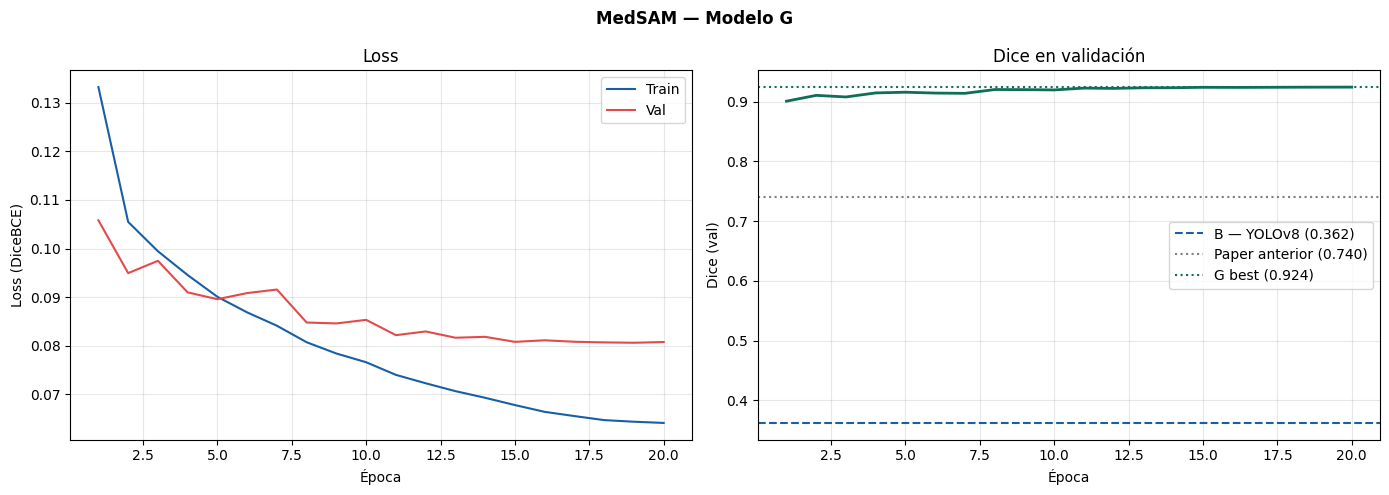

In [13]:
# Curva de entrenamiento
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train', color='#185FA5')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val',   color='#E24B4A')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss (DiceBCE)')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df['epoch'], hist_df['val_dice'], color='#0F6E56', lw=2)
axes[1].axhline(0.362, color='#185FA5', ls='--', lw=1.5, label='B — YOLOv8 (0.362)')
axes[1].axhline(0.740, color='gray',    ls=':',  lw=1.5, label='Paper anterior (0.740)')
axes[1].axhline(best_val_dice, color='#0F6E56', ls=':', lw=1.5,
                label=f'G best ({best_val_dice:.3f})')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Dice (val)')
axes[1].set_title('Dice en validación'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('MedSAM — Modelo G', fontweight='bold')
plt.tight_layout()
plt.savefig(str(DRIVE_ROOT/'models'/'medsam_G_training.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7 — Evaluación Dice por clase en test set

In [14]:
ckpt = torch.load(CKPT_DIR/'medsam_G_best.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'✔ Checkpoint cargado — época {ckpt["epoch"]} | val_dice={ckpt["val_dice"]:.4f}')


def dice_iou(p, g):
    p, g  = p.astype(bool), g.astype(bool)
    inter = (p&g).sum(); union = (p|g).sum()
    return (2*inter/(p.sum()+g.sum()) if (p.sum()+g.sum())>0 else 1.0,
            inter/union if union>0 else 1.0)


@torch.no_grad()
def eval_medsam(model, split_df, model_name, conf=0.5):
    model.eval()
    dice_cls = {c: [] for c in range(NUM_CLASSES)}
    iou_cls  = {c: [] for c in range(NUM_CLASSES)}
    l5_log   = []

    for _, row in split_df.iterrows():
        ip   = DATASET_ROOT / row[COL_IMAGE]
        mp   = DATASET_ROOT / row[COL_MASK]
        bp   = DATASET_ROOT / row[COL_BINARY]
        stem = ip.stem

        emb_path = EMBED_CACHE / f'{stem}.pt'
        if not emb_path.exists(): continue
        emb = torch.load(emb_path, map_location=DEVICE).squeeze(0)  # [256,64,64]

        gt = gt_from_png_aligned(mp, bp, 1024, 1024)

        for c in range(NUM_CLASSES):
            if gt[c].sum() == 0: continue
            bbox = mask_to_bbox(gt[c], margin=5)
            if bbox is None: continue
            bbox_t = torch.tensor([bbox], dtype=torch.float32).to(DEVICE)

            pred_logit = model(bbox_t, emb.unsqueeze(0))  # [1,1,256,256]
            pred_256   = (torch.sigmoid(pred_logit[0,0]) > conf).cpu().numpy().astype(np.uint8)
            pred_1024  = cv2.resize(pred_256, (1024,1024), interpolation=cv2.INTER_NEAREST)

            d, iou = dice_iou(pred_1024, gt[c])
            dice_cls[c].append(d); iou_cls[c].append(iou)

            if c == 16:
                l5_log.append({
                    'image'   : ip.name, 'model': model_name,
                    'split'   : 'Scoliosis' if stem.startswith('S_') else 'Normal',
                    'dice': d, 'iou': iou,
                    'gt_px'   : int(gt[c].sum()), 'pred_px': int(pred_1024.sum()),
                    'detected': pred_1024.sum() > 0
                })

    return dice_cls, iou_cls, l5_log


print('Evaluando Modelo G en test set...')
dice_g, iou_g, l5_g = eval_medsam(model, test_f, 'G_MedSAM_filt_preproc')
print('✔ Evaluación completa')

✔ Checkpoint cargado — época 20 | val_dice=0.9243
Evaluando Modelo G en test set...
✔ Evaluación completa


In [15]:
# Tabla comparativa
dice_b_v = dict(zip(range(17),[0.6687,0.5934,0.4228,0.2685,0.3287,0.2690,
                                0.3083,0.2588,0.1873,0.2984,0.2777,0.3068,
                                0.2980,0.3543,0.4224,0.4858,0.4041]))
try:
    prev     = pd.read_csv(DRIVE_ROOT/'models'/'comparacion_EF.csv')
    dice_e_v = dict(zip(range(17), prev['dice_E'].values))
    print('✔ Modelo E cargado')
except:
    dice_e_v = {c: 0. for c in range(17)}
    print('Modelo E no disponible')

print(f'\n{"Clase":<6} {"B":>7} {"E":>7} {"G-MedSAM":>10} {"Mejor":>7}')
print('─'*45)
rows = []
for c in range(NUM_CLASSES):
    db  = dice_b_v.get(c, 0.)
    de  = dice_e_v.get(c, 0.)
    dg  = np.mean(dice_g[c]) if dice_g[c] else 0.
    bl  = ['B','E','G'][[db,de,dg].index(max(db,de,dg))]
    tag = ' ◄L5' if c==16 else ''
    print(f'{CLASS_NAMES[c]:<6} {db:>7.4f} {de:>7.4f} {dg:>10.4f} {bl:>7}{tag}')
    rows.append({'clase':CLASS_NAMES[c],'dice_B':db,'dice_E':de,'dice_G':dg,'mejor':bl,
                 'iou_G':np.mean(iou_g[c]) if iou_g[c] else 0.})

print('─'*45)
mb = np.mean([r['dice_B'] for r in rows])
me = np.mean([r['dice_E'] for r in rows])
mg = np.mean([r['dice_G'] for r in rows])
print(f'{"MEAN":<6} {mb:>7.4f} {me:>7.4f} {mg:>10.4f}')
print(f'\n  B  YOLOv8 filtrado         : {mb:.4f}')
print(f'  E  YOLOv8 filtrado+preproc : {me:.4f}  Δ vs B: {me-mb:+.4f}')
print(f'  G  MedSAM filtrado+preproc : {mg:.4f}  Δ vs B: {mg-mb:+.4f}')
print(f'  Paper anterior             : 0.7400')

pd.DataFrame(rows).to_csv(DRIVE_ROOT/'models'/'comparacion_G.csv', index=False)
print('\n✔ Tabla guardada')

✔ Modelo E cargado

Clase        B       E   G-MedSAM   Mejor
─────────────────────────────────────────────
T1      0.6687  0.5766     0.8883       G
T2      0.5934  0.5193     0.8914       G
T3      0.4228  0.4403     0.8877       G
T4      0.2685  0.3798     0.8955       G
T5      0.3287  0.4507     0.8931       G
T6      0.2690  0.3319     0.8917       G
T7      0.3083  0.2913     0.9067       G
T8      0.2588  0.2762     0.8987       G
T9      0.1873  0.2206     0.8872       G
T10     0.2984  0.2612     0.8931       G
T11     0.2777  0.2707     0.8908       G
T12     0.3068  0.3216     0.9096       G
L1      0.2980  0.2966     0.9092       G
L2      0.3543  0.3218     0.9036       G
L3      0.4224  0.2719     0.9119       G
L4      0.4858  0.4953     0.9104       G
L5      0.4041  0.3148     0.9058       G ◄L5
─────────────────────────────────────────────
MEAN    0.3619  0.3553     0.8985

  B  YOLOv8 filtrado         : 0.3619
  E  YOLOv8 filtrado+preproc : 0.3553  Δ vs B: -0.0066


═══ L5 — Modelo G ═══════════════════════
             dice                 detected
             mean  median     std     mean
split                                     
Normal     0.9095  0.9215  0.0215      1.0
Scoliosis  0.8913  0.8913  0.0061      1.0


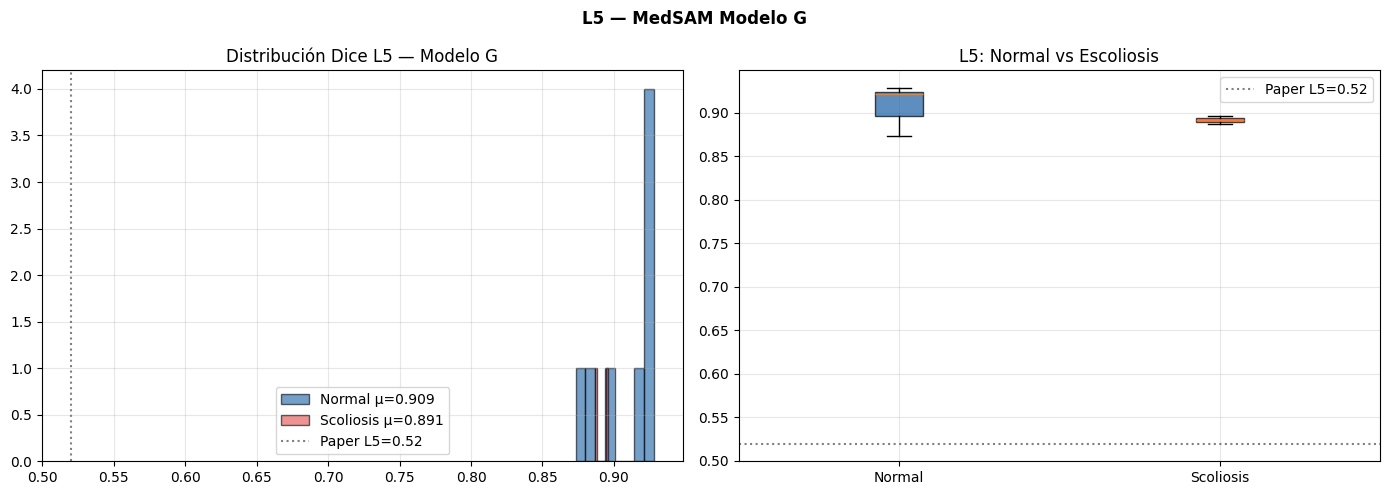

In [16]:
# Análisis L5
if l5_g:
    l5_df = pd.DataFrame(l5_g)
    print('═══ L5 — Modelo G ═══════════════════════')
    print(l5_df.groupby('split')[['dice','detected']].agg(
        {'dice':['mean','median','std'],'detected':'mean'}
    ).round(4).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for split, col in [('Normal','#185FA5'),('Scoliosis','#E24B4A')]:
        sub = l5_df[l5_df['split']==split]['dice']
        axes[0].hist(sub, bins=8, alpha=0.6, color=col, edgecolor='k',
                     label=f'{split} μ={sub.mean():.3f}')
    axes[0].axvline(0.52, color='gray', ls=':', lw=1.5, label='Paper L5=0.52')
    axes[0].set_title('Distribución Dice L5 — Modelo G')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    bp_data = [l5_df[l5_df['split']=='Normal']['dice'].values,
               l5_df[l5_df['split']=='Scoliosis']['dice'].values]
    bp = axes[1].boxplot(bp_data, labels=['Normal','Scoliosis'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#185FA5'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#E24B4A'); bp['boxes'][1].set_alpha(0.7)
    axes[1].axhline(0.52, color='gray', ls=':', lw=1.5, label='Paper L5=0.52')
    axes[1].set_title('L5: Normal vs Escoliosis'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('L5 — MedSAM Modelo G', fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(DRIVE_ROOT/'models'/'l5_G.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [17]:
import shutil
shutil.copy(CKPT_DIR/'medsam_G_best.pth', DRIVE_ROOT/'models'/'medsam_G_best.pth')

l5_df_  = pd.DataFrame(l5_g) if l5_g else pd.DataFrame()
l5_nor  = l5_df_[l5_df_['split']=='Normal']['dice'].mean()     if len(l5_df_) else 0.
l5_sco  = l5_df_[l5_df_['split']=='Scoliosis']['dice'].mean()  if len(l5_df_) else 0.

print('\n'+'='*60)
print('RESUMEN FINAL — Modelo G (MedSAM)')
print('='*60)
print(f'''
B  YOLOv8 filtrado sin preproc    : {mb:.4f}
E  YOLOv8 filtrado + preproc      : {me:.4f}  Δ vs B: {me-mb:+.4f}
G  MedSAM filtrado + preproc      : {mg:.4f}  Δ vs B: {mg-mb:+.4f}
Paper anterior                    : 0.7400

L5 Modelo G:
  Normal    : {l5_nor:.4f}
  Scoliosis : {l5_sco:.4f}
  Paper L5  : 0.5200
''')
print('='*60)


RESUMEN FINAL — Modelo G (MedSAM)

B  YOLOv8 filtrado sin preproc    : 0.3619
E  YOLOv8 filtrado + preproc      : 0.3553  Δ vs B: -0.0066
G  MedSAM filtrado + preproc      : 0.8985  Δ vs B: +0.5366
Paper anterior                    : 0.7400

L5 Modelo G:
  Normal    : 0.9095
  Scoliosis : 0.8913
  Paper L5  : 0.5200



In [18]:
# ── Visualización Predicción vs GT ────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Paleta de colores para las 17 clases (igual en pred y GT)
np.random.seed(0)
PALETTE = np.random.randint(60, 230, (NUM_CLASSES, 3), dtype=np.uint8)
PALETTE_NORM = PALETTE / 255.0

def build_overlay(image_proc, gt_dict, pred_dict, alpha=0.45):
    """
    Construye imagen con overlay de máscaras coloreadas.
    gt_dict / pred_dict: {class_id: máscara binaria 1024×1024}
    """
    base = cv2.cvtColor(image_proc, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    gt_overlay   = base.copy()
    pred_overlay = base.copy()

    for c in range(NUM_CLASSES):
        color = PALETTE_NORM[c]
        if gt_dict[c].sum() > 0:
            m = gt_dict[c].astype(bool)
            gt_overlay[m] = (1 - alpha) * gt_overlay[m] + alpha * color
        if pred_dict[c].sum() > 0:
            m = pred_dict[c].astype(bool)
            pred_overlay[m] = (1 - alpha) * pred_overlay[m] + alpha * color

    return np.clip(gt_overlay, 0, 1), np.clip(pred_overlay, 0, 1)


def build_diff_map(gt_dict, pred_dict):
    """
    Mapa de diferencia píxel a píxel entre GT y predicción.
    Verde = coincide, Rojo = falso positivo, Azul = falso negativo.
    """
    H, W   = 1024, 1024
    diff   = np.zeros((H, W, 3), dtype=np.float32)
    for c in range(NUM_CLASSES):
        gt   = gt_dict[c].astype(bool)
        pred = pred_dict[c].astype(bool)
        # Verdadero positivo → verde
        diff[gt  & pred] = [0.2, 0.8, 0.2]
        # Falso negativo (GT sí, pred no) → azul
        diff[gt  & ~pred] = [0.2, 0.4, 0.9]
        # Falso positivo (GT no, pred sí) → rojo
        diff[~gt & pred]  = [0.9, 0.2, 0.2]
    return diff


@torch.no_grad()
def visualize_prediction(model, row, title=None, conf=0.5, save_path=None):
    """
    Genera figura con 4 paneles:
    1. Imagen preprocesada
    2. GT con overlay de máscaras
    3. Predicción con overlay de máscaras
    4. Mapa de diferencia (TP=verde, FN=azul, FP=rojo)
    """
    model.eval()
    ip   = DATASET_ROOT / row[COL_IMAGE]
    mp   = DATASET_ROOT / row[COL_MASK]
    bp   = DATASET_ROOT / row[COL_BINARY]
    stem = ip.stem

    # Preprocesar imagen
    curve = load_spine_curve(stem)
    proc  = preprocess_image(ip, bp, curve, target_size=(1024,1024))
    if proc is None:
        print(f'No se pudo preprocesar {stem}'); return

    # GT alineado
    gt = gt_from_png_aligned(mp, bp, 1024, 1024)

    # Cargar embedding y predecir clase por clase
    emb_path = EMBED_CACHE / f'{stem}.pt'
    if not emb_path.exists():
        print(f'Embedding no encontrado para {stem}'); return
    emb = torch.load(emb_path, map_location=DEVICE).squeeze(0)

    pred = {c: np.zeros((1024,1024), np.uint8) for c in range(NUM_CLASSES)}
    dice_per_class = {}
    for c in range(NUM_CLASSES):
        if gt[c].sum() == 0: continue
        bbox = mask_to_bbox(gt[c], margin=5)
        if bbox is None: continue
        bbox_t     = torch.tensor([bbox], dtype=torch.float32).to(DEVICE)
        logit      = model(bbox_t, emb.unsqueeze(0).to(DEVICE))
        pred_256   = (torch.sigmoid(logit[0,0]) > conf).cpu().numpy().astype(np.uint8)
        pred[c]    = cv2.resize(pred_256, (1024,1024), interpolation=cv2.INTER_NEAREST)
        d, _       = dice_iou(pred[c], gt[c])
        dice_per_class[c] = d

    mean_dice = np.mean(list(dice_per_class.values())) if dice_per_class else 0.

    # Construir overlays
    gt_ov, pred_ov = build_overlay(proc, gt, pred)
    diff_map       = build_diff_map(gt, pred)

    # ── Figura estilo paper ──────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 8))
    fig.patch.set_facecolor('white')

    img_rgb = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb, cmap='gray'); axes[0].axis('off')
    axes[0].set_title('(a) Imagen preprocesada', fontsize=11, fontweight='bold', pad=8)

    axes[1].imshow(gt_ov);   axes[1].axis('off')
    axes[1].set_title('(b) Ground Truth', fontsize=11, fontweight='bold', pad=8)

    axes[2].imshow(pred_ov); axes[2].axis('off')
    axes[2].set_title(f'(c) Predicción MedSAM\nDice={mean_dice:.3f}',
                      fontsize=11, fontweight='bold', pad=8)

    axes[3].imshow(diff_map); axes[3].axis('off')
    axes[3].set_title('(d) Mapa de diferencia', fontsize=11, fontweight='bold', pad=8)

    # Leyenda del mapa de diferencia
    legend_elements = [
        mpatches.Patch(color=(0.2,0.8,0.2), label='Verdadero positivo'),
        mpatches.Patch(color=(0.2,0.4,0.9), label='Falso negativo (GT no detectado)'),
        mpatches.Patch(color=(0.9,0.2,0.2), label='Falso positivo (predicción extra)'),
    ]
    axes[3].legend(handles=legend_elements, loc='lower center',
                   bbox_to_anchor=(0.5, -0.08), fontsize=8,
                   framealpha=0.9, ncol=1)

    # Leyenda de clases vertebrales
    legend_cls = [mpatches.Patch(
        color=PALETTE_NORM[c], label=CLASS_NAMES[c],
        alpha=0.85) for c in range(NUM_CLASSES)]
    fig.legend(handles=legend_cls, loc='lower center',
               bbox_to_anchor=(0.5, -0.01), ncol=17,
               fontsize=7.5, framealpha=0.9,
               title='Clases vertebrales', title_fontsize=8)

    suptitle = title or f'Paciente {stem} — MedSAM Segmentación Vertebral'
    stype    = 'Escoliosis' if stem.startswith('S_') else 'Normal'
    fig.suptitle(f'{suptitle}\n{stype} | Dice medio: {mean_dice:.3f}',
                 fontsize=13, fontweight='bold', y=1.01)

    plt.tight_layout(rect=[0, 0.04, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f'✔ Guardado en {save_path}')
    plt.show()
    return dice_per_class

── Normal ──────────────────────────────────────
✔ Guardado en /content/drive/MyDrive/models/viz_normal.png


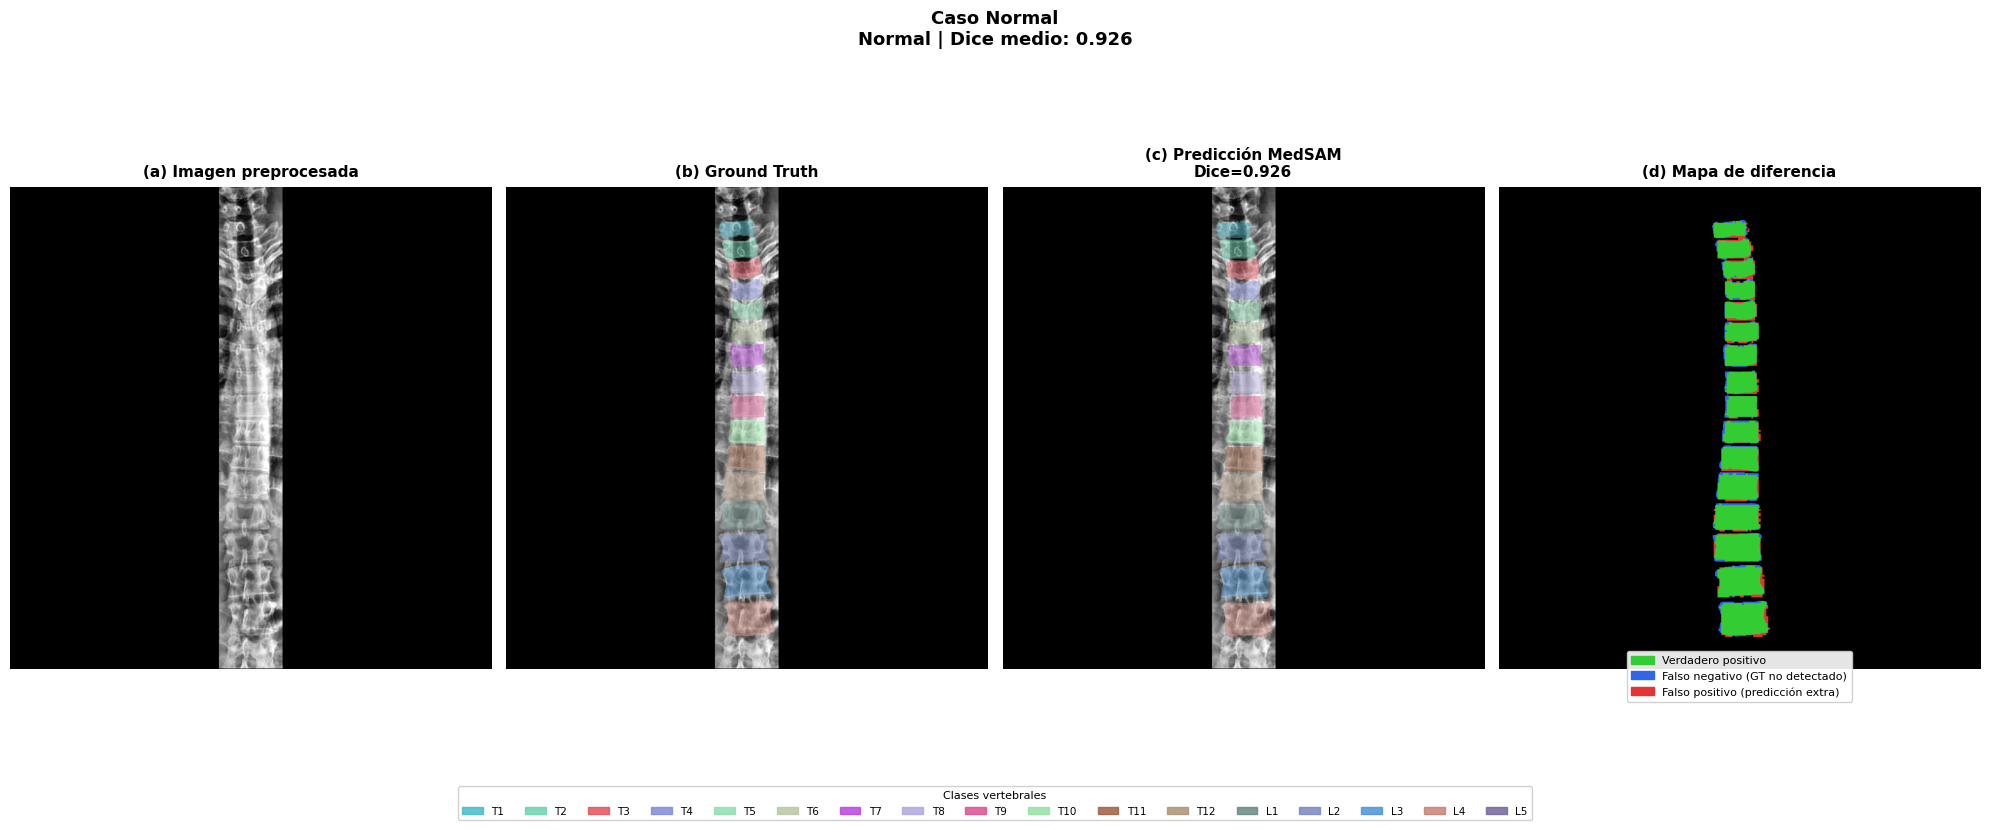

── Escoliosis ──────────────────────────────────
✔ Guardado en /content/drive/MyDrive/models/viz_scoliosis.png


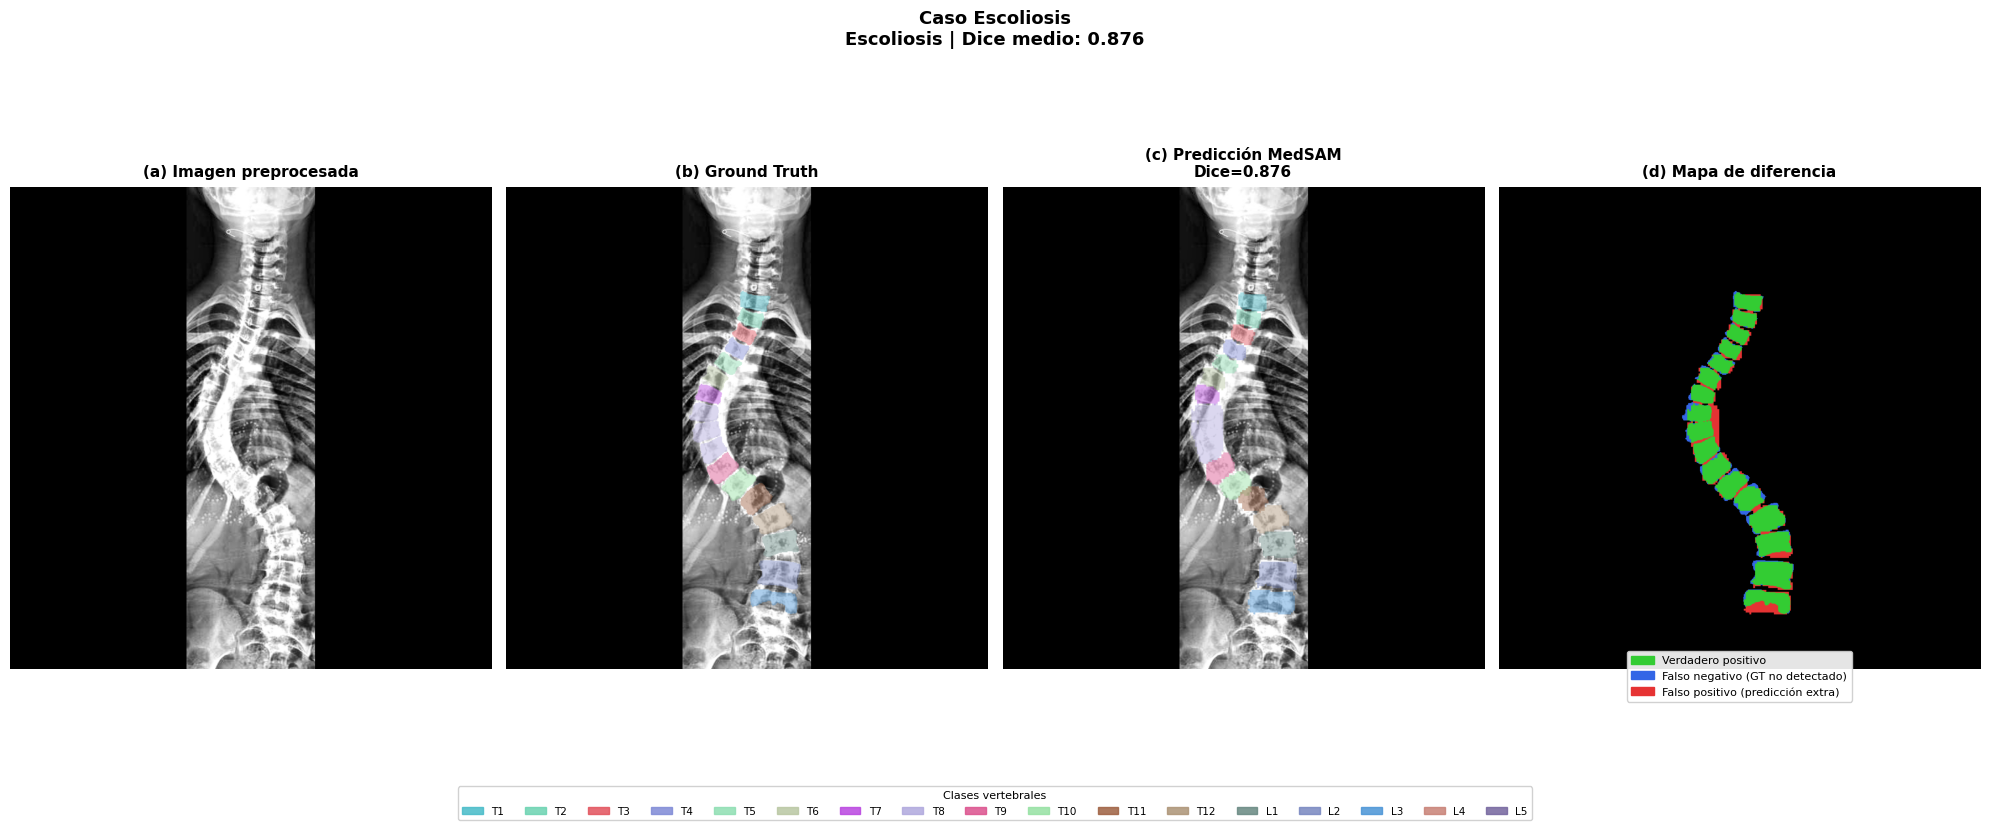


── Peor caso L5 Escoliosis: S_103 ──
✔ Guardado en /content/drive/MyDrive/models/viz_worst_l5.png


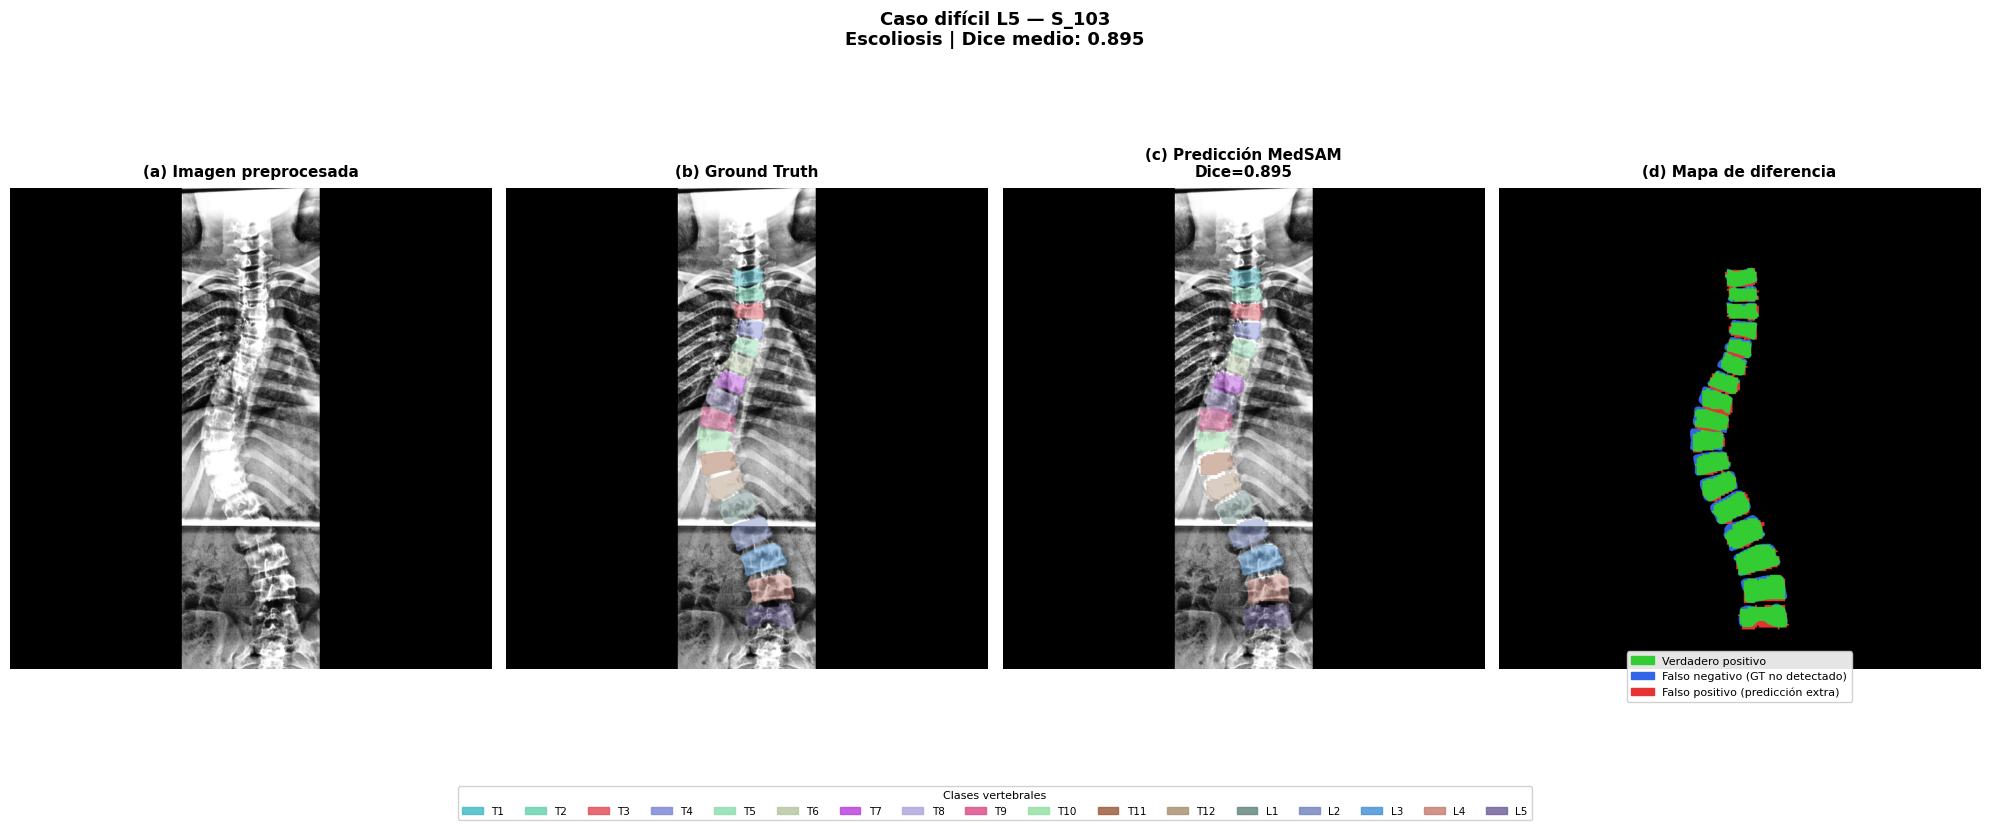

In [19]:
# ── Ejecutar visualización ─────────────────────────────────────

# Visualizar 1 caso Normal y 1 caso Escoliosis del test set
normal_rows    = test_f[~test_f[COL_IMAGE].str.contains('Scoliosis')]
scoliosis_rows = test_f[test_f[COL_IMAGE].str.contains('Scoliosis')]

# Caso Normal
if len(normal_rows) > 0:
    row_n = normal_rows.iloc[0]
    print('── Normal ──────────────────────────────────────')
    dice_n = visualize_prediction(
        model, row_n,
        title='Caso Normal',
        save_path=str(DRIVE_ROOT/'models'/'viz_normal.png')
    )

# Caso Escoliosis
if len(scoliosis_rows) > 0:
    row_s = scoliosis_rows.iloc[0]
    print('── Escoliosis ──────────────────────────────────')
    dice_s = visualize_prediction(
        model, row_s,
        title='Caso Escoliosis',
        save_path=str(DRIVE_ROOT/'models'/'viz_scoliosis.png')
    )

# Visualizar el peor caso L5 en escoliosis (más interesante para la tesis)
if l5_g:
    l5_df_viz = pd.DataFrame(l5_g)
    worst_l5  = l5_df_viz[l5_df_viz['split']=='Scoliosis'].nsmallest(1,'dice')
    if len(worst_l5) > 0:
        worst_stem = Path(worst_l5.iloc[0]['image']).stem
        worst_row  = test_f[test_f[COL_IMAGE].apply(
            lambda p: Path(p).stem == worst_stem)].iloc[0]
        print(f'\n── Peor caso L5 Escoliosis: {worst_stem} ──')
        visualize_prediction(
            model, worst_row,
            title=f'Caso difícil L5 — {worst_stem}',
            save_path=str(DRIVE_ROOT/'models'/'viz_worst_l5.png')
        )

In [21]:
def build_overlay(image_proc, gt_dict, pred_dict, dice_per_class=None,
                  show_labels=True, alpha=0.45):
    """
    Overlay de máscaras con etiquetas de clase y Dice score.
    """
    base         = cv2.cvtColor(image_proc, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    gt_overlay   = base.copy()
    pred_overlay = base.copy()

    gt_labels   = []  # (cx, cy, texto, color)
    pred_labels = []

    for c in range(NUM_CLASSES):
        color = PALETTE_NORM[c]

        # GT overlay + centroide
        if gt_dict[c].sum() > 0:
            m = gt_dict[c].astype(bool)
            gt_overlay[m] = (1-alpha)*gt_overlay[m] + alpha*color
            if show_labels:
                ys, xs = np.where(m)
                cx, cy = int(xs.mean()), int(ys.mean())
                gt_labels.append((cx, cy, CLASS_NAMES[c], color))

        # Pred overlay + centroide + Dice
        if pred_dict[c].sum() > 0:
            m = pred_dict[c].astype(bool)
            pred_overlay[m] = (1-alpha)*pred_overlay[m] + alpha*color
            if show_labels:
                ys, xs = np.where(m)
                cx, cy = int(xs.mean()), int(ys.mean())
                d      = dice_per_class.get(c, 0.) if dice_per_class else 0.
                label  = f'{CLASS_NAMES[c]}\n{d:.2f}'
                pred_labels.append((cx, cy, label, color))

    return (np.clip(gt_overlay,   0, 1),
            np.clip(pred_overlay, 0, 1),
            gt_labels, pred_labels)


def add_labels_to_axis(ax, labels, fontsize=6.5):
    """
    Dibuja etiquetas con fondo semitransparente sobre el eje.
    Cada etiqueta tiene borde del color de la clase.
    """
    for cx, cy, text, color in labels:
        ax.text(
            cx, cy, text,
            fontsize    = fontsize,
            fontweight  = 'bold',
            color       = 'white',
            ha          = 'center',
            va          = 'center',
            multialignment = 'center',
            bbox        = dict(
                boxstyle    = 'round,pad=0.25',
                facecolor   = (*color, 0.75),   # color de clase semitransparente
                edgecolor   = 'white',
                linewidth   = 0.8
            )
        )


@torch.no_grad()
def visualize_prediction(model, row, title=None, conf=0.5, save_path=None):
    model.eval()
    ip   = DATASET_ROOT / row[COL_IMAGE]
    mp   = DATASET_ROOT / row[COL_MASK]
    bp   = DATASET_ROOT / row[COL_BINARY]
    stem = ip.stem

    curve = load_spine_curve(stem)
    proc  = preprocess_image(ip, bp, curve, target_size=(1024,1024))
    if proc is None:
        print(f'No se pudo preprocesar {stem}'); return

    gt = gt_from_png_aligned(mp, bp, 1024, 1024)

    emb_path = EMBED_CACHE / f'{stem}.pt'
    if not emb_path.exists():
        print(f'Embedding no encontrado para {stem}'); return
    emb = torch.load(emb_path, map_location=DEVICE).squeeze(0)

    pred = {c: np.zeros((1024,1024), np.uint8) for c in range(NUM_CLASSES)}
    dice_per_class = {}
    for c in range(NUM_CLASSES):
        if gt[c].sum() == 0: continue
        bbox = mask_to_bbox(gt[c], margin=5)
        if bbox is None: continue
        bbox_t   = torch.tensor([bbox], dtype=torch.float32).to(DEVICE)
        logit    = model(bbox_t, emb.unsqueeze(0).to(DEVICE))
        pred_256 = (torch.sigmoid(logit[0,0]) > conf).cpu().numpy().astype(np.uint8)
        pred[c]  = cv2.resize(pred_256, (1024,1024), interpolation=cv2.INTER_NEAREST)
        d, _     = dice_iou(pred[c], gt[c])
        dice_per_class[c] = d

    mean_dice = np.mean(list(dice_per_class.values())) if dice_per_class else 0.

    # Overlays con etiquetas
    gt_ov, pred_ov, gt_labels, pred_labels = build_overlay(
        proc, gt, pred, dice_per_class=dice_per_class, show_labels=True
    )
    diff_map = build_diff_map(gt, pred)

    # ── Figura estilo paper ───────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(22, 9))
    fig.patch.set_facecolor('white')

    # Panel (a) — imagen preprocesada
    axes[0].imshow(cv2.cvtColor(proc, cv2.COLOR_BGR2RGB), cmap='gray')
    axes[0].axis('off')
    axes[0].set_title('(a) Imagen preprocesada',
                      fontsize=11, fontweight='bold', pad=10)

    # Panel (b) — GT con etiquetas de clase
    axes[1].imshow(gt_ov)
    add_labels_to_axis(axes[1], gt_labels, fontsize=6.5)
    axes[1].axis('off')
    axes[1].set_title('(b) Ground Truth',
                      fontsize=11, fontweight='bold', pad=10)

    # Panel (c) — Predicción con etiquetas clase + Dice
    axes[2].imshow(pred_ov)
    add_labels_to_axis(axes[2], pred_labels, fontsize=6.5)
    axes[2].axis('off')
    axes[2].set_title(f'(c) Predicción MedSAM  |  Dice={mean_dice:.3f}',
                      fontsize=11, fontweight='bold', pad=10)

    # Panel (d) — mapa de diferencia
    axes[3].imshow(diff_map)
    axes[3].axis('off')
    axes[3].set_title('(d) Mapa de diferencia',
                      fontsize=11, fontweight='bold', pad=10)

    # Leyenda mapa de diferencia
    legend_diff = [
        mpatches.Patch(color=(0.2,0.8,0.2), label='Verdadero positivo (TP)'),
        mpatches.Patch(color=(0.2,0.4,0.9), label='Falso negativo (FN)'),
        mpatches.Patch(color=(0.9,0.2,0.2), label='Falso positivo (FP)'),
    ]
    axes[3].legend(handles=legend_diff, loc='lower center',
                   bbox_to_anchor=(0.5, -0.06), fontsize=8.5,
                   framealpha=0.95, ncol=1, edgecolor='gray')

    # Leyenda global de clases vertebrales
    legend_cls = [
        mpatches.Patch(color=PALETTE_NORM[c], label=CLASS_NAMES[c], alpha=0.85)
        for c in range(NUM_CLASSES)
    ]
    fig.legend(handles=legend_cls, loc='lower center',
               bbox_to_anchor=(0.5, -0.02), ncol=17,
               fontsize=8, framealpha=0.95, edgecolor='gray',
               title='Clases vertebrales', title_fontsize=9)

    # Título principal
    stype = 'Escoliosis' if stem.startswith('S_') else 'Normal'
    fig.suptitle(
        f'{title or stem}  —  {stype}  |  Dice medio: {mean_dice:.3f}',
        fontsize=13, fontweight='bold', y=1.02
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f'✔ Guardado: {save_path}')
    plt.show()
    return dice_per_class

✔ S_79 encontrado en split: Scoliosis
✔ Guardado: /content/drive/MyDrive/models/viz_S79.png


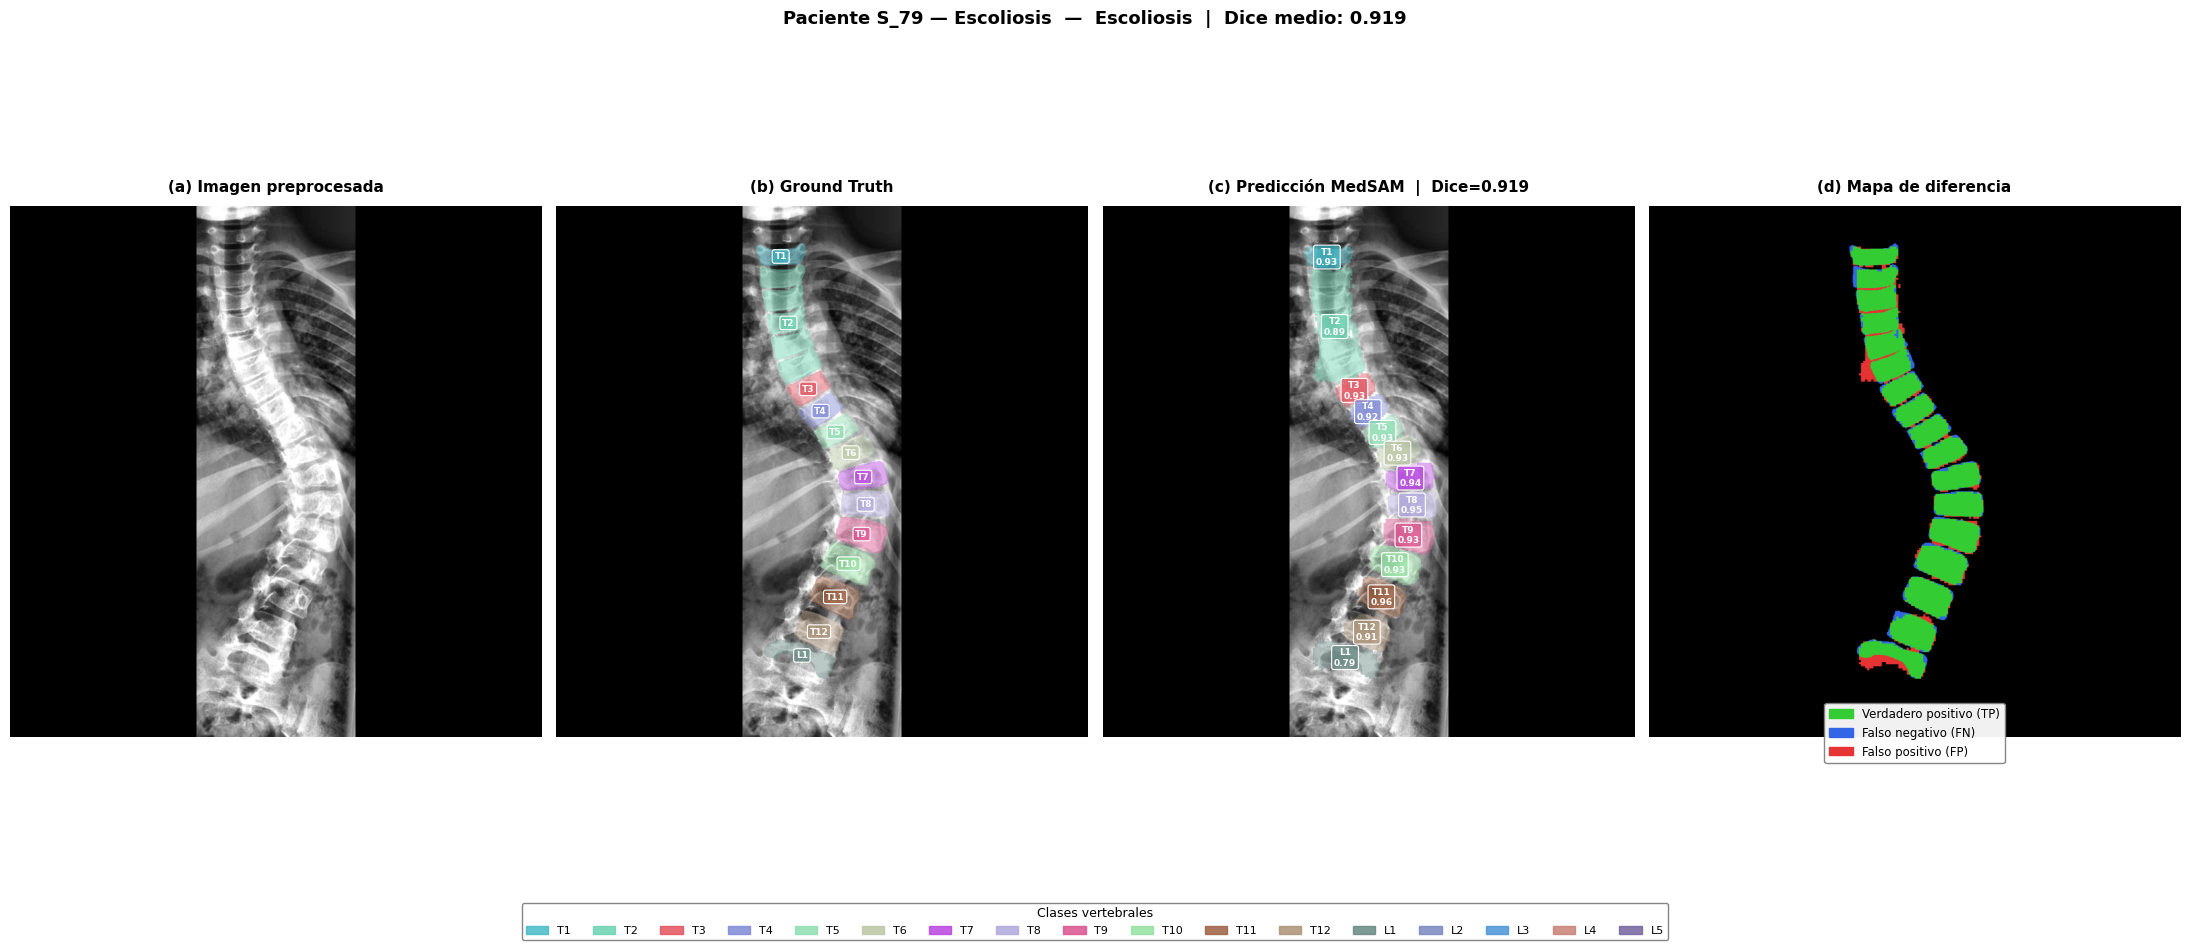


Dice por clase — S_79:
Clase    Dice
──────────────
T1     0.9310
T2     0.8897
T3     0.9251
T4     0.9244
T5     0.9272
T6     0.9308
T7     0.9383
T8     0.9525
T9     0.9302
T10    0.9338
T11    0.9565
T12    0.9128
L1     0.7912
MEAN   0.9187


In [22]:
# ── Visualización S_79 ────────────────────────────────────────
row_s79 = df[df[COL_IMAGE].apply(lambda p: Path(p).stem == 'S_79')]

if len(row_s79) == 0:
    print('No encontrado en df principal — buscando en test_f...')
    row_s79 = test_f[test_f[COL_IMAGE].apply(lambda p: Path(p).stem == 'S_79')]

if len(row_s79) == 0:
    print('S_79 no está en el test set — buscando en todos los splits...')
    all_df  = pd.concat([train_f, val_f, test_f])
    row_s79 = all_df[all_df[COL_IMAGE].apply(lambda p: Path(p).stem == 'S_79')]

if len(row_s79) == 0:
    print('❌ S_79 no encontrado en ningún split')
else:
    print(f'✔ S_79 encontrado en split: {row_s79.iloc[0][COL_SPLIT]}')
    dice_s79 = visualize_prediction(
        model,
        row_s79.iloc[0],
        title='Paciente S_79 — Escoliosis',
        save_path=str(DRIVE_ROOT / 'models' / 'viz_S79.png')
    )
    # Imprimir Dice por clase
    if dice_s79:
        print(f'\nDice por clase — S_79:')
        print(f'{"Clase":<6} {"Dice":>6}')
        print('─' * 14)
        for c, d in sorted(dice_s79.items()):
            flag = ' ◄' if c == 16 else ''
            print(f'{CLASS_NAMES[c]:<6} {d:>6.4f}{flag}')
        print(f'{"MEAN":<6} {np.mean(list(dice_s79.values())):>6.4f}')

In [23]:
# ── Guardar modelo completo en Drive ──────────────────────────
import shutil, json
from datetime import datetime

SAVE_DIR = DRIVE_ROOT / 'models' / 'medsam_G'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# 1. Guardar pesos del modelo
ckpt_dst = SAVE_DIR / f'medsam_G_best_{timestamp}.pth'
shutil.copy(CKPT_DIR / 'medsam_G_best.pth', ckpt_dst)
print(f'✔ Pesos guardados: {ckpt_dst}')

# 2. Guardar metadatos del experimento
meta = {
    'modelo'          : 'G — MedSAM ViT-B fine-tuning',
    'arquitectura'    : 'MedSAM vit_b — solo Mask Decoder entrenado',
    'dataset'         : 'Filtrado (≥13 clases) — 104 train / 24 val / 25 test',
    'preprocesamiento': 'CLAHE + mapa espinal gaussiano + crop ROI + padding 1024x1024',
    'epochs'          : NUM_EPOCHS,
    'best_epoch'      : int(ckpt['epoch']),
    'best_val_dice'   : float(ckpt['val_dice']),
    'lr'              : LR,
    'batch_size'      : dl_train.batch_size,
    'optimizer'       : 'AdamW',
    'loss'            : 'DiceBCE',
    'clases'          : CLASS_NAMES,
    'num_classes'     : NUM_CLASSES,
    'seed'            : SEED,
    'timestamp'       : timestamp,
    'dice_test_mean'  : float(np.mean([np.mean(dice_g[c])
                                       for c in range(NUM_CLASSES)
                                       if dice_g[c]])),
}
meta_path = SAVE_DIR / f'medsam_G_meta_{timestamp}.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print(f'✔ Metadatos guardados: {meta_path}')

# 3. Guardar Dice por clase en CSV
rows_export = []
for c in range(NUM_CLASSES):
    rows_export.append({
        'clase'     : CLASS_NAMES[c],
        'class_id'  : c,
        'dice_mean' : float(np.mean(dice_g[c])) if dice_g[c] else 0.,
        'dice_std'  : float(np.std(dice_g[c]))  if dice_g[c] else 0.,
        'iou_mean'  : float(np.mean(iou_g[c]))  if iou_g[c] else 0.,
        'n_samples' : len(dice_g[c])
    })
csv_path = SAVE_DIR / f'medsam_G_dice_por_clase_{timestamp}.csv'
pd.DataFrame(rows_export).to_csv(csv_path, index=False)
print(f'✔ Dice por clase guardado: {csv_path}')

# 4. Guardar análisis L5
if l5_g:
    l5_path = SAVE_DIR / f'medsam_G_l5_{timestamp}.csv'
    pd.DataFrame(l5_g).to_csv(l5_path, index=False)
    print(f'✔ Análisis L5 guardado: {l5_path}')

print(f'\n✔ Todo guardado en: {SAVE_DIR}')
print(f'\nContenido:')
for f in sorted(SAVE_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

✔ Pesos guardados: /content/drive/MyDrive/models/medsam_G/medsam_G_best_20260515_1500.pth
✔ Metadatos guardados: /content/drive/MyDrive/models/medsam_G/medsam_G_meta_20260515_1500.json
✔ Dice por clase guardado: /content/drive/MyDrive/models/medsam_G/medsam_G_dice_por_clase_20260515_1500.csv
✔ Análisis L5 guardado: /content/drive/MyDrive/models/medsam_G/medsam_G_l5_20260515_1500.csv

✔ Todo guardado en: /content/drive/MyDrive/models/medsam_G

Contenido:
  medsam_G_best_20260515_1500.pth  (375.1 MB)
  medsam_G_dice_por_clase_20260515_1500.csv  (0.0 MB)
  medsam_G_l5_20260515_1500.csv  (0.0 MB)
  medsam_G_meta_20260515_1500.json  (0.0 MB)


In [24]:
# ── Guardar modelo completo en Drive ──────────────────────────
import shutil, json
from datetime import datetime

SAVE_DIR = DRIVE_ROOT / 'models' / 'medsam_G'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# 1. Guardar pesos del modelo
ckpt_dst = SAVE_DIR / f'medsam_G_best_{timestamp}.pth'
shutil.copy(CKPT_DIR / 'medsam_G_best.pth', ckpt_dst)
print(f'✔ Pesos guardados: {ckpt_dst}')

# 2. Guardar metadatos del experimento
meta = {
    'modelo'          : 'G — MedSAM ViT-B fine-tuning',
    'arquitectura'    : 'MedSAM vit_b — solo Mask Decoder entrenado',
    'dataset'         : 'Filtrado (≥13 clases) — 104 train / 24 val / 25 test',
    'preprocesamiento': 'CLAHE + mapa espinal gaussiano + crop ROI + padding 1024x1024',
    'epochs'          : NUM_EPOCHS,
    'best_epoch'      : int(ckpt['epoch']),
    'best_val_dice'   : float(ckpt['val_dice']),
    'lr'              : LR,
    'batch_size'      : dl_train.batch_size,
    'optimizer'       : 'AdamW',
    'loss'            : 'DiceBCE',
    'clases'          : CLASS_NAMES,
    'num_classes'     : NUM_CLASSES,
    'seed'            : SEED,
    'timestamp'       : timestamp,
    'dice_test_mean'  : float(np.mean([np.mean(dice_g[c])
                                       for c in range(NUM_CLASSES)
                                       if dice_g[c]])),
}
meta_path = SAVE_DIR / f'medsam_G_meta_{timestamp}.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print(f'✔ Metadatos guardados: {meta_path}')

# 3. Guardar Dice por clase en CSV
rows_export = []
for c in range(NUM_CLASSES):
    rows_export.append({
        'clase'     : CLASS_NAMES[c],
        'class_id'  : c,
        'dice_mean' : float(np.mean(dice_g[c])) if dice_g[c] else 0.,
        'dice_std'  : float(np.std(dice_g[c]))  if dice_g[c] else 0.,
        'iou_mean'  : float(np.mean(iou_g[c]))  if iou_g[c] else 0.,
        'n_samples' : len(dice_g[c])
    })
csv_path = SAVE_DIR / f'medsam_G_dice_por_clase_{timestamp}.csv'
pd.DataFrame(rows_export).to_csv(csv_path, index=False)
print(f'✔ Dice por clase guardado: {csv_path}')

# 4. Guardar análisis L5
if l5_g:
    l5_path = SAVE_DIR / f'medsam_G_l5_{timestamp}.csv'
    pd.DataFrame(l5_g).to_csv(l5_path, index=False)
    print(f'✔ Análisis L5 guardado: {l5_path}')

print(f'\n✔ Todo guardado en: {SAVE_DIR}')
print(f'\nContenido:')
for f in sorted(SAVE_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

✔ Pesos guardados: /content/drive/MyDrive/models/medsam_G/medsam_G_best_20260515_1501.pth
✔ Metadatos guardados: /content/drive/MyDrive/models/medsam_G/medsam_G_meta_20260515_1501.json
✔ Dice por clase guardado: /content/drive/MyDrive/models/medsam_G/medsam_G_dice_por_clase_20260515_1501.csv
✔ Análisis L5 guardado: /content/drive/MyDrive/models/medsam_G/medsam_G_l5_20260515_1501.csv

✔ Todo guardado en: /content/drive/MyDrive/models/medsam_G

Contenido:
  medsam_G_best_20260515_1500.pth  (375.1 MB)
  medsam_G_best_20260515_1501.pth  (375.1 MB)
  medsam_G_dice_por_clase_20260515_1500.csv  (0.0 MB)
  medsam_G_dice_por_clase_20260515_1501.csv  (0.0 MB)
  medsam_G_l5_20260515_1500.csv  (0.0 MB)
  medsam_G_l5_20260515_1501.csv  (0.0 MB)
  medsam_G_meta_20260515_1500.json  (0.0 MB)
  medsam_G_meta_20260515_1501.json  (0.0 MB)
